In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Create folder for plots
os.makedirs("plots_lab5", exist_ok=True)

In [4]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [5]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [6]:
model = Sequential()

model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=vocab_size, output_dim=128))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 184ms/step - accuracy: 0.7663 - loss: 0.4890 - val_accuracy: 0.8536 - val_loss: 0.3566
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.8575 - loss: 0.3515 - val_accuracy: 0.8342 - val_loss: 0.3867
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 191ms/step - accuracy: 0.8727 - loss: 0.3049 - val_accuracy: 0.7516 - val_loss: 0.4972
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 193ms/step - accuracy: 0.8955 - loss: 0.2638 - val_accuracy: 0.8308 - val_loss: 0.3982
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 193ms/step - accuracy: 0.9133 - loss: 0.2259 - val_accuracy: 0.8218 - val_loss: 0.4171


In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8260 - loss: 0.4208
Test Accuracy: 0.8259599804878235


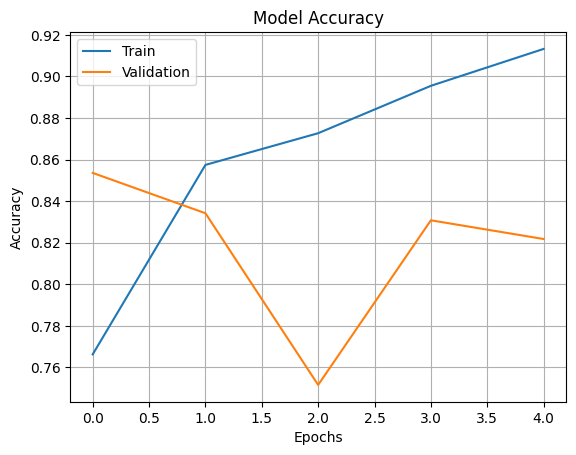

In [9]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig("plots_lab5/accuracy.png")
plt.show()

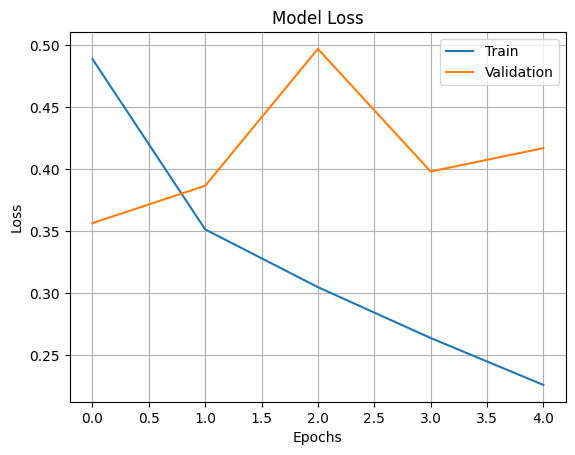

In [10]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig("plots_lab5/loss.png")
plt.show()

In [11]:
y_pred = model.predict(X_test, verbose=0)
y_pred_binary = (y_pred > 0.5).astype(int)

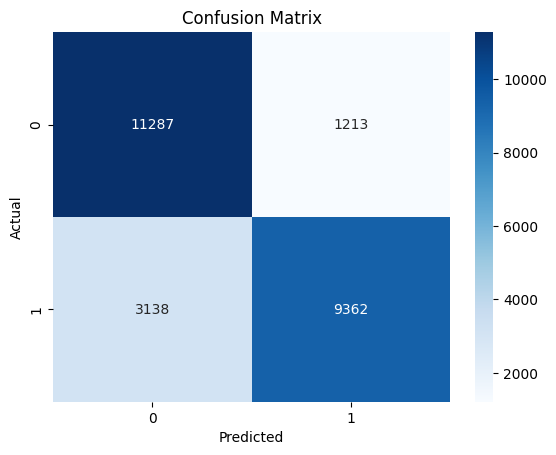

In [12]:
cm = confusion_matrix(y_test, y_pred_binary)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig("plots_lab5/confusion_matrix.png")
plt.show()

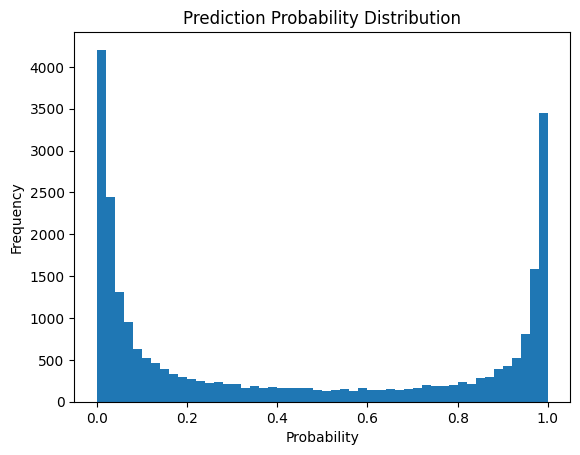

In [13]:
plt.figure()
plt.hist(y_pred, bins=50)
plt.title('Prediction Probability Distribution')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.savefig("plots_lab5/prediction_distribution.png")
plt.show()

In [14]:
print(classification_report(y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.78      0.90      0.84     12500
           1       0.89      0.75      0.81     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.82     25000
weighted avg       0.83      0.83      0.82     25000

